# 3.2.3 复数模态与阻尼旋转

## 学习目标与先修知识

能把复数（complex number）表示还原为二维实运动，用特征值（eigenvalue）实部与虚部分别解释衰减和旋转，并识别特征向量（eigenvector）不足时的处理边界。

先修：上一节的特征值、模态（mode）与矩阵指数（matrix exponential）；中学三角函数与指数函数（exponential function）。 [复习上一节](02-特征值模态与矩阵传播.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

人工偏差系统的一条曲线正负交替，另一条也交替，但时间错开。怎样用一个“衰减加旋转”的规则解释它们？普通两室封闭交换会出现同样的旋转吗？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK = '#008bfb', '#ff0051'

## 初步实验

先计算一个具体情形，再解释这些数是怎样相互制约的。

In [2]:
z=1+0j
print('连续乘 i：',[z*(1j)**n for n in range(5)])
print('Python 用 j 表示虚数单位；数学正文通常写 i。')

连续乘 i： [(1+0j), 1j, (-1+0j), -1j, (1+0j)]
Python 用 j 表示虚数单位；数学正文通常写 i。


## 模型假设

偏差模型（model）的两个坐标同为 U，表示相对参考值的偏离，正负分别对应高于和低于参考值。取 alpha=.2/T、omega=1/T、初始 [2,0] U。角度用弧度，omega*t 无量纲（dimensionless）。另用一个上三角偏差模型说明重复特征值的边界。

## 数学解释与推导

复数 $z=x_1+i x_2$ 只是把两个实数写在一起，其中 $i^2=-1$。复共轭（complex conjugate） $\bar z=x_1-i x_2$ 反转虚部，模长（modulus） $|z|=\sqrt{x_1^2+x_2^2}$；乘 i 将平面向量（vector）逆时针旋转四分之一圈。单位圆上角度 θ 的点写成 $\cos\theta+i\sin\theta$。

欧拉公式（Euler’s formula） $e^{i\theta}=\cos\theta+i\sin\theta$ 把旋转与指数联系起来：可从两边在 θ=0 相等且导数（derivative）均等于 i 乘自身来理解。于是
$$\dot z=(-\alpha+i\omega)z\quad\Rightarrow\quad z(t)=e^{-\alpha t}(\cos\omega t+i\sin\omega t)z(0).$$
分离实部和虚部就得到
$$\dot x=\begin{pmatrix}-\alpha&-\omega\\\omega&-\alpha\end{pmatrix}x,$$
$$x_1(t)=e^{-\alpha t}(x_{10}\cos\omega t-x_{20}\sin\omega t),\quad
x_2(t)=e^{-\alpha t}(x_{10}\sin\omega t+x_{20}\cos\omega t).$$
特征方程为 $(\lambda+\alpha)^2+\omega^2=0$，故特征值为 $-\alpha\pm i\omega$。实矩阵（matrix）的非实特征值成复共轭对；二者联合给实轨迹（trajectory）。α>0 控制衰减，ω>0 给周期 $2\pi/\omega$。α=0 只旋转，ω=0 只缩放；二者都为零则完全不动。

对比封闭两室交换：特征方程为 $\lambda(\lambda+a+b)=0$，只有 0 与 −(a+b) 两个实值。总量不变，分配单调靠近对应平衡（equilibrium），没有旋转模态。

最后考虑 $M=\begin{pmatrix}-r&q\\0&-r\end{pmatrix}$。q≠0 时只有一个独立特征向量，V 不可逆。先求 $x_2=e^{-rt}x_{20}$，再把第一式乘积分因子（integrating factor） $e^{rt}$：$\frac{d}{dt}(e^{rt}x_1)=q x_{20}$，积分得
$$x_1=e^{-rt}(x_{10}+qt x_{20}).$$
这是一种 Jordan 块（Jordan block）的例子，包含 $t e^{-rt}$，说明相同特征值也可能有不同暂态。重复特征值不总意味着不能对角化，例如 −I 可以；关键是独立特征向量是否足够。一般矩阵的轨迹可用矩阵指数计算。

## 核心实现

把刚才的关系逐项写入函数。

In [3]:
def damped(alpha, omega, initial, times):
    import math
    values = []
    for t in times:
        co, si, decay = math.cos(omega*t), math.sin(omega*t), math.exp(-alpha*t)
        values.append([decay*(co*initial[0]-si*initial[1]),
                       decay*(si*initial[0]+co*initial[1])])
    return [[-alpha, omega], [-alpha, -omega]], values
def jordan(rate, coupling, initial, times):
    import math
    return [[math.exp(-rate*t)*(initial[0]+coupling*t*initial[1]),
             math.exp(-rate*t)*initial[1]] for t in times]

## 对照实验

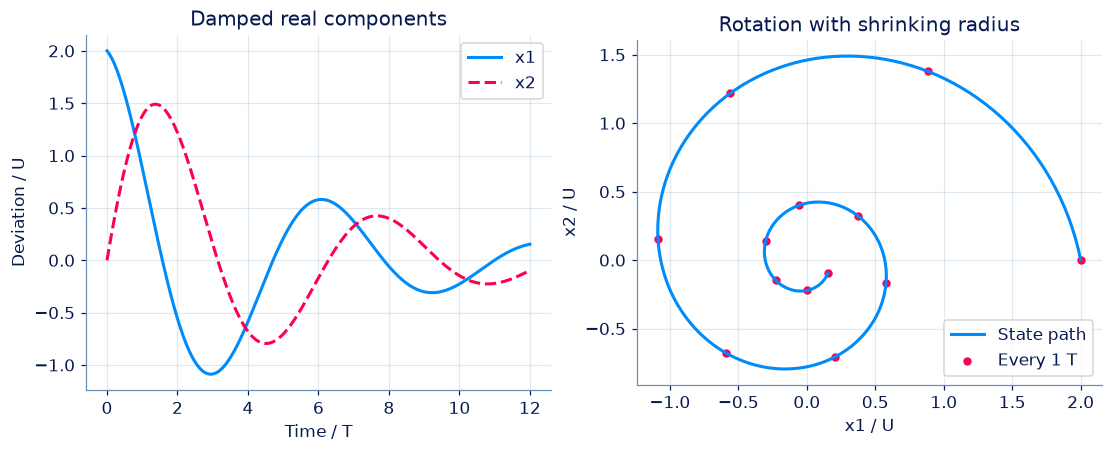

| t / T | Jordan x1 / U | Jordan x2 / U |
| --- | --- | --- |
| 0 | 0 | 1 |
| 1 | 0.367879 | 0.367879 |
| 2 | 0.270671 | 0.135335 |
| 3 | 0.149361 | 0.0497871 |

In [4]:
times=np.linspace(0,12,301)
_,states=damped(.2,1,[2,0],times);states=np.array(states)
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].plot(times,states[:,0],color=BLUE,label='x1');axes[0].plot(times,states[:,1],'--',color=PINK,label='x2')
axes[0].set(xlabel='Time / T',ylabel='Deviation / U',title='Damped real components');axes[0].legend()
axes[1].plot(states[:,0],states[:,1],color=BLUE,label='State path')
marks=np.arange(0,13,1);_,marked=damped(.2,1,[2,0],marks);marked=np.array(marked)
axes[1].scatter(marked[:,0],marked[:,1],color=PINK,s=20,label='Every 1 T')
axes[1].set(xlabel='x1 / U',ylabel='x2 / U',title='Rotation with shrinking radius');axes[1].set_aspect('equal');axes[1].legend();plt.show()
t=np.array([0,1,2,3.]);j=np.array(jordan(1,1,[0,1],t))
display(Markdown(show_table(['t / T','Jordan x1 / U','Jordan x2 / U'],zip(t,*j.T))))

## 结果解释

两条实曲线在零点两侧交替，但半径持续减小。右图的等时间点先后绕向原点；负坐标表示负偏差。Jordan 例的第一分量可先增后减，即使两个特征值都是 −1/T。

### 独立核对

半径公式来自旋转保持长度，独立于逐分量实现；差分残差（residual）仅作数值检查。对 Jordan 例还可手工求导验证耦合方程。

In [5]:
np.testing.assert_allclose(np.linalg.norm(states,axis=1),2*np.exp(-.2*times),atol=1e-12)
M=np.array([[-.2,-1],[1,-.2]])
for t in [.3,1.2]:
    h=1e-5
    states3=np.array(damped(.2,1,[2,0],[t-h,t,t+h])[1])
    np.testing.assert_allclose((states3[2]-states3[0])/(2*h),M@states3[1],atol=1e-9)
np.testing.assert_allclose(jordan(1,1,[0,1],[1])[0],[math.exp(-1)]*2)
np.testing.assert_allclose(damped(.2,0,[-1,2],[2])[1][0],np.array([-1,2])*math.exp(-.4))
assert damped(0,0,[2,1],[0,9])[1]==[[2,1],[2,1]]
print('长度闭式、微分方程残差、Jordan 特例与零参数边界通过。')

长度闭式、微分方程残差、Jordan 特例与零参数边界通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/03-02-线性状态空间与动态模态/explore/)：改变一个条件，观察时间曲线与状态空间（state space）中的运动，再回到本节解释。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：把复共轭模态还原成实轨迹

人工偏差模型（model） x′=[[-alpha,−omega],[omega,−alpha]]x，两个分量为相同单位 U 的偏离量，可为负，不是非负所追踪物质总量（tracked amount）。返回特征值（eigenvalue）的实虚部与实数轨迹（trajectory）。

**函数与代码模板**

```python
def solve(
    alpha: float,
    omega: float,
    initial: list[float],
    times: list[float],
) -> tuple[list[list[float]], list[list[float]]]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `alpha` | `float` | 衰减率。 | 1/T |
| `omega` | `float` | 旋转角频率。 | 1/T |
| `initial` | `list[float]` | 两个起始偏离量。 | U |
| `times` | `list[float]` | 观察时刻。 | T |

**返回值**

按以下顺序返回元组：(eigenvalues, states)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `eigenvalues` | `list[list[float]]` | [[实部,+虚部],[实部,−虚部]]；omega=0 时两行相同。 | 1/T |
| `states` | `list[list[float]]` | 每个时刻的 [x1,x2] 实数状态（state）。 | U |

**计算规则**

特征值=−alpha±i omega；x1=exp(−alpha*t)(initial[0]cos(omega*t)−initial[1]sin(omega*t))；x2=exp(−alpha*t)(initial[0]sin(omega*t)+initial[1]cos(omega*t))。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 0≤alpha≤2；0≤omega≤4；initial 长度 2，分量绝对值≤10；times 长度 1—30，0≤t≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| alpha | 衰减率。 | 1 | 1/T |
| omega | 旋转角频率。 | 2 | 1/T |
| initial | 两个起始偏离量。 | [1, 0] | U |
| times | 观察时刻。 | [0, 0.5] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
alpha = 1
omega = 2
initial = [1, 0]
times = [0, 0.5]

result = solve(alpha, omega, initial, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| eigenvalues | [[实部,+虚部],[实部,−虚部]]；omega=0 时两行相同。 | [[-1, 2], [-1, -2]] | 1/T |
| states | 每个时刻的 [x1,x2] 实数状态（state）。 | [[1.0, 0.0], [0.32770991402245986, 0.5103779515445728]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[-1, 2], [-1, -2]],
                   [[1.0, 0.0],
                    [0.32770991402245986,
                     0.5103779515445728]])
```

**样例解释**

特征值为 −1±2i。t=0.5 时转过 1 弧度，长度乘 exp(−0.5)，两分量仍为实数。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：把复共轭模态还原成实轨迹](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-damped)

### 第 2 题 · Python 计算题：特征向量不够时仍可求解

人工偏差模型（model） M=[[-rate,coupling],[0,−rate]]，无输入（input）。当 coupling≠0 时只有一个独立特征向量（eigenvector）。先解第二条方程，再代入第一条，返回实轨迹（trajectory）。

**函数与代码模板**

```python
def solve(
    rate: float,
    coupling: float,
    initial: list[float],
    times: list[float],
) -> list[list[float]]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rate` | `float` | 两条方程的衰减率。 | 1/T |
| `coupling` | `float` | 第二分量对第一分量的作用系数。 | 1/T |
| `initial` | `list[float]` | 两个起始偏离量。 | U |
| `times` | `list[float]` | 所求时刻。 | T |

**返回值**

直接返回 states（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[list[float]]` | 每个时刻的 [x1,x2]。 | U |

**计算规则**

x2(t)=exp(−rate*t)initial[1]；x1(t)=exp(−rate*t)(initial[0]+coupling*t*initial[1])。

**约束与边界**

- 所有数值有限；不修改输入列表。
- 0≤rate,coupling≤2；initial 分量绝对值≤10；times 长度 1—20，0≤t≤10。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| rate | 两条方程的衰减率。 | 1 | 1/T |
| coupling | 第二分量对第一分量的作用系数。 | 1 | 1/T |
| initial | 两个起始偏离量。 | [0, 1] | U |
| times | 所求时刻。 | [0, 1] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
rate = 1
coupling = 1
initial = [0, 1]
times = [0, 1]

result = solve(rate, coupling, initial, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 每个时刻的 [x1,x2]。 | [[0.0, 1.0], [0.36787944117144233, 0.36787944117144233]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.0, 1.0],
                   [0.36787944117144233,
                    0.36787944117144233]]
```

**样例解释**

t=1 时两分量均为 exp(−1)；x1 含 t 因子，不能用两个相同的纯指数模态（mode）假装完成分解。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：特征向量不够时仍可求解](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-jordan)

### 第 3 题 · 多项选择题：虚数不是虚构的物理量

对 z=x1+i x2，i²=−1，z′=(−alpha+i omega)z。哪些解释正确？

- **A.** i omega 部分描述平面旋转。
- **B.** 实状态（state） x1,x2 必须变成复数（complex number）测量。
- **C.** e^(iθ)=cosθ+i sinθ 把复指数与实平面联系起来。
- **D.** alpha>0 时半径按指数缩小。

[作答：虚数不是虚构的物理量](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-complex-meaning)

### 第 4 题 · 多项选择题：封闭两室会自发振荡吗

普通封闭双向交换的 a,b>0。特征值（eigenvalue）为 0 与 −(a+b)。哪些成立？

- **A.** 总量模态（mode）保持不变。
- **B.** 差异向平衡（equilibrium）分配指数衰减。
- **C.** 必然产生周期性正负摆动。
- **D.** 人工旋转模型（model）的负偏差不能解释成负所追踪物质总量（tracked amount）。

[作答：封闭两室会自发振荡吗](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-exchange-no-oscillation)

### 第 5 题 · 单项选择题：能否总把矩阵对角化

矩阵（matrix） [[−1,1],[0,−1]] 只有一个独立特征向量（eigenvector）。正确处理是？

- **A.** 强行求两列相同向量（vector）组成的矩阵的逆。
- **B.** 认为微分方程没有解。
- **C.** 按耦合方程求解，或用不依赖完整特征向量组的矩阵指数（matrix exponential）方法。
- **D.** 删掉非对角元素，认为特征值（eigenvalue）一样就没有区别。

[作答：能否总把矩阵对角化](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-defective-limit)

**进一步阅读**

[MIT 一阶系统课程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-iv-first-order-systems/)：矩阵方法、矩阵指数、相图与线性化。